<a href="https://colab.research.google.com/github/Tarunk005/student-pass-prediction-random-forest/blob/main/student_random_forest_gridsearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import logging
import warnings

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

In [26]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger(__name__)

logger.info("Project Started Successfully.")

In [4]:
import pandas as pd
import logging

logger = logging.getLogger(__name__)

df = pd.read_csv("student_performance.csv")

logger.info("Dataset loaded successfully.")
print(df.head())

   study_hours  attendance_pct  assignments_done  pass
0          5.3            41.5                 4     0
1          2.2            84.2                10     0
2          4.9            41.9                 1     0
3          2.2            76.1                 8     0
4          5.9            82.1                 6     0


DATASET OVERVIEW
Number of Rows    : 2000
Number of Columns : 4

Column Names:
['study_hours', 'attendance_pct', 'assignments_done', 'pass']

Data Types:
study_hours         float64
attendance_pct      float64
assignments_done      int64
pass                  int64
dtype: object

Missing Values:
study_hours         0
attendance_pct      0
assignments_done    0
pass                0
dtype: int64

Duplicate Rows:
1
SUMMARY STATISTICS


,study_hours,attendance_pct,assignments_done,pass
count,2000.000000,2000.000000,2000.000000,2000.0000
mean,4.281400,70.367800,5.127500,0.5050
std,2.174978,16.890562,3.191447,0.5001
min,0.500000,40.100000,0.000000,0.0000
25%,2.300000,55.900000,2.000000,0.0000
50%,4.300000,70.500000,5.000000,1.0000
75%,6.200000,84.800000,8.000000,1.0000
max,8.000000,100.000000,10.000000,1.0000


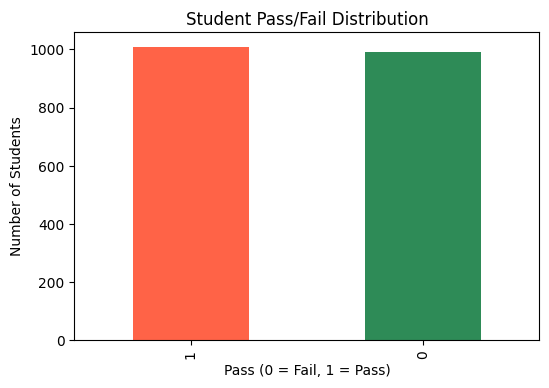

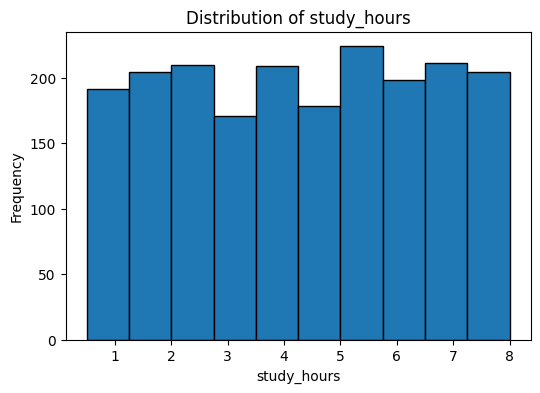

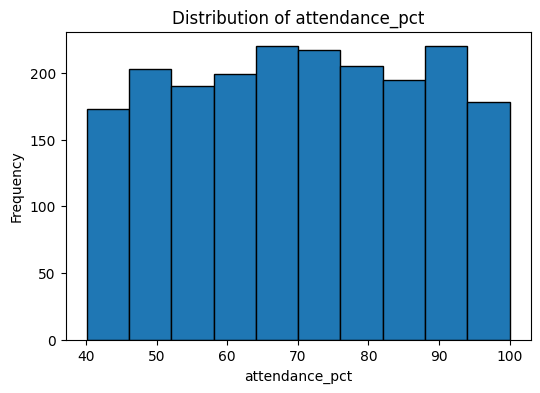

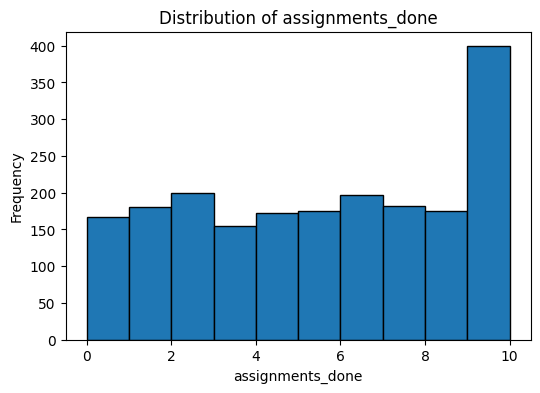

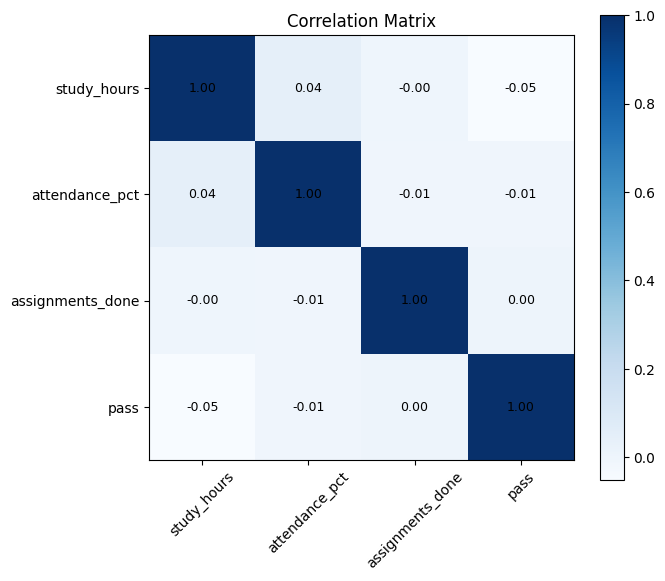

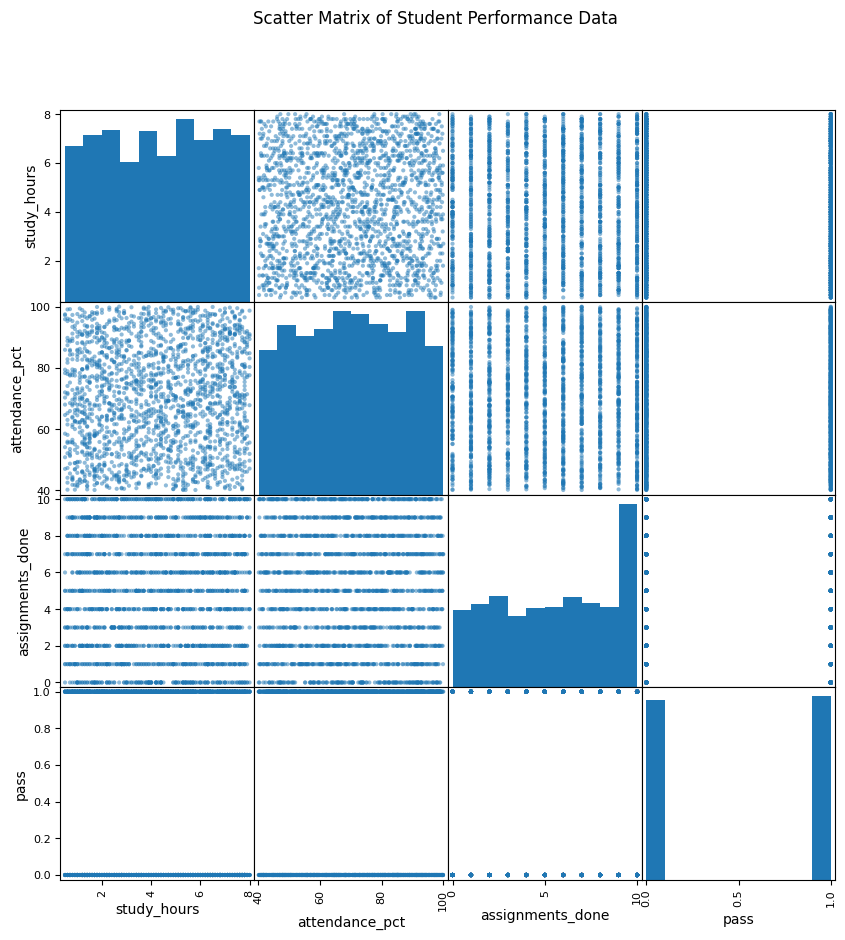

TARGET VARIABLE DISTRIBUTION


,Class,Count,Percentage
0,Fail (0),990,49.5
1,Pass (1),1010,50.5


In [27]:
# Exploratory Data Analysis (EDA)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

#Summary Statistics
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

display(df.describe())

#Class Distribution
plt.figure(figsize=(6,4))

df["pass"].value_counts().plot(
    kind="bar",
    color=["tomato", "seagreen"]
)

plt.title("Student Pass/Fail Distribution")
plt.xlabel("Pass (0 = Fail, 1 = Pass)")
plt.ylabel("Number of Students")

plt.show()

#Feature Distributions
features = [
    "study_hours",
    "attendance_pct",
    "assignments_done"
]

for feature in features:

    plt.figure(figsize=(6,4))

    plt.hist(
        df[feature],
        bins=10,
        edgecolor="black"
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

#Correlation Matrix
correlation = df.corr()

plt.figure(figsize=(7,6))
plt.imshow(correlation, cmap="Blues")
plt.colorbar()
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

#Pairwise Relationships
pd.plotting.scatter_matrix(
    df,
    figsize=(10,10),
    diagonal="hist"
)

plt.suptitle("Scatter Matrix of Student Performance Data")
plt.show()

#Target Variable Summary
print("=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)

target_counts = df["pass"].value_counts().sort_index()

summary = pd.DataFrame({
    "Class": ["Fail (0)", "Pass (1)"],
    "Count": target_counts.values,
    "Percentage": (target_counts.values / len(df) * 100).round(2)
})

display(summary)

</>Markdown
## Key Observations

- The dataset contains no missing values or duplicate records.
- The target classes are reasonably balanced.
- Students with higher study hours, attendance percentage, and assignment completion tend to have a higher likelihood of passing.
- The correlation matrix indicates positive relationships between the input features and the target variable.
- The dataset is suitable for training a supervised classification model.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving student_performance.csv to student_performance.csv


In [5]:
print("=" * 50)
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nFirst Five Rows:")
display(df.head())

Dataset Shape: (2000, 4)

Column Names:
['study_hours', 'attendance_pct', 'assignments_done', 'pass']

Missing Values:
study_hours         0
attendance_pct      0
assignments_done    0
pass                0
dtype: int64

Data Types:
study_hours         float64
attendance_pct      float64
assignments_done      int64
pass                  int64
dtype: object

First Five Rows:


,study_hours,attendance_pct,assignments_done,pass
0,5.3,41.5,4,0
1,2.2,84.2,10,0
2,4.9,41.9,1,0
3,2.2,76.1,8,0
4,5.9,82.1,6,0


In [10]:
# Separate features and target

X = df.drop("pass", axis=1)
y = df["pass"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

logger.info("Train-test split completed.")

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Features Shape : (2000, 3)
Target Shape   : (2000,)
Training Samples : 1600
Testing Samples  : 400


In [11]:
# Initialize Random Forest Classifier

rf_model = RandomForestClassifier(
    random_state=42
)

logger.info("Random Forest model initialized.")

In [12]:
# Hyperparameter Grid

param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [3, 5, 10]
}

print("Hyperparameter Grid:")
print(param_grid)

Hyperparameter Grid:
{'n_estimators': [10, 50, 100], 'max_depth': [3, 5, 10]}


In [13]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    return_train_score=True
)

logger.info("GridSearchCV configured successfully.")

In [14]:
logger.info("Starting Grid Search...")

grid_search.fit(X_train, y_train)

logger.info("Grid Search completed successfully.")

In [18]:
logger.info(f"Best Parameters: {grid_search.best_params_}")

print("Best Parameters:")
print(grid_search.best_params_)

#Log the Best Cross-Validation F1 Score
logger.info(f"Best Cross-Validated F1 Score: {grid_search.best_score_:.4f}")
print(f"Best CV Weighted F1 Score: {grid_search.best_score_:.4f}")


# Best Model View
best_model = grid_search.best_estimator_
print(best_model)

Best Parameters:
{'max_depth': 3, 'n_estimators': 100}
Best CV Weighted F1 Score: 0.4995
RandomForestClassifier(max_depth=3, random_state=42)


Test Weighted F1 Score : 0.5333
Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.55      0.42      0.47       198
           1       0.54      0.66      0.59       202

    accuracy                           0.54       400
   macro avg       0.54      0.54      0.53       400
weighted avg       0.54      0.54      0.53       400



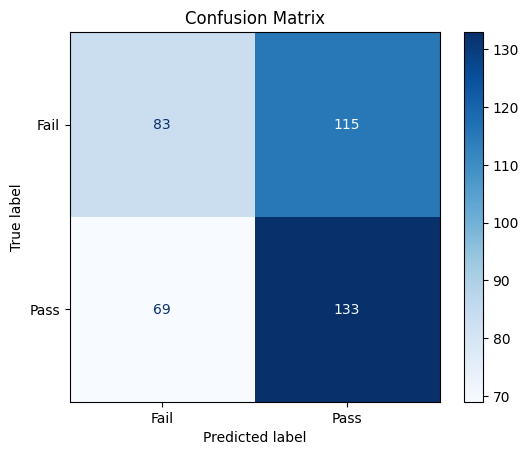

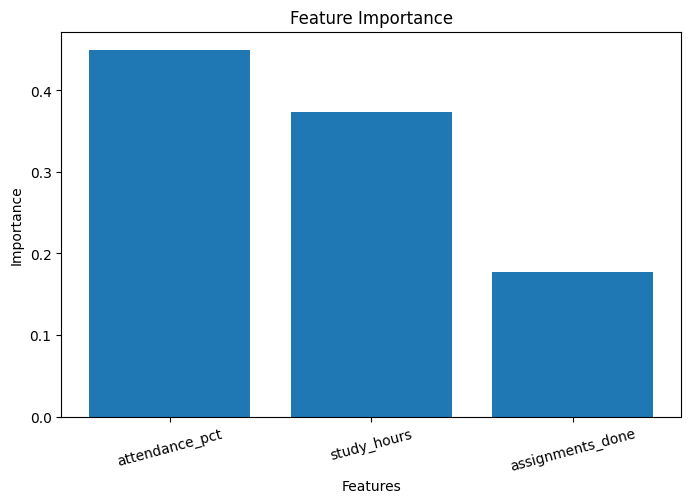

In [24]:
# Evaluate the best model on the test set

y_pred = best_model.predict(X_test)

test_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

logger.info(f"Test Weighted F1 Score: {test_f1:.4f}")

print("=" * 50)
print(f"Test Weighted F1 Score : {test_f1:.4f}")
print("=" * 50)

#Classification Report
print("Classification Report")
print("-" * 50)

print(classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

#Store Grid Search Results in DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

logger.info("Grid Search results stored in DataFrame.")

results_df.head()

#Display Required Columns
results_df[
    [
        "params",
        "mean_test_score",
        "rank_test_score"
    ]
]

#Save Results as CSV
results_df.to_csv(
    "grid_search_results.csv",
    index=False
)

logger.info("Grid Search results saved successfully.")

#Save the Best Model
joblib.dump(
    best_model,
    "best_random_forest_model.pkl"
)

logger.info("Best model saved successfully.")

#Feature Importance
feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

#Plot Feature Importance
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=15)
plt.show()

In [25]:
#Final Project Summary

print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print(f"Dataset Shape              : {df.shape}")
print(f"Training Samples           : {len(X_train)}")
print(f"Testing Samples            : {len(X_test)}")
print(f"Best Parameters            : {grid_search.best_params_}")
print(f"Best CV Weighted F1 Score  : {grid_search.best_score_:.4f}")
print(f"Test Weighted F1 Score     : {test_f1:.4f}")

print("=" * 60)
print("Project Completed Successfully")
print("=" * 60)

PROJECT SUMMARY
Dataset Shape              : (2000, 4)
Training Samples           : 1600
Testing Samples            : 400
Best Parameters            : {'max_depth': 3, 'n_estimators': 100}
Best CV Weighted F1 Score  : 0.4995
Test Weighted F1 Score     : 0.5333
Project Completed Successfully
